In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from atmo3 import grid_utils as gutl
from atmo3 import box
from atmo3 import atm_utils as au
from atmo3 import constants as const
import matplotlib.pyplot as plt

# ==============================================================================
# 1. Define the Geometric Workspace
# ==============================================================================
# Calculate the vertical grid dimensions
Lz = 9750.0  # Total height of the box in meters
dz = 30.0    # Vertical step size in meters
Nz = int(Lz / dz)  # Yields exactly 325 cells

L_0_q = 500 #m


dt_simulation = 2.0  # in seconds
vx = 5.0  # in m/s the wind speed along the x-axis

# Update your N and Lbox arrays (assuming you keep the X and Y axes the same),  we make Nz and Lz match the lidar profiles
N = jnp.array([2048, 256, Nz])                 # [256, 256, 325]
Lbox = jnp.array([40000.0, 20000.0, Lz])      # [20000.0, 20000.0, 9750.0]
site_altitude = 2400.0                        # Your new site altitude

# Initialize the standalone grid workspace
grid_wsp = gutl.GridWorkspace(N=N, Lbox=Lbox, site_altitude=site_altitude)

# Extract the exact 1D altitude axis 
# This will automatically start at 2400m and go up to 12150m (2400 + 9750) with 30m steps
z_axis_grid = grid_wsp.grid_axis(axis=2, altitude_axis=True)

In [2]:
from matplotlib import pyplot as plt
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [3]:
import numpy as np
from lidar_sigma_pwv import lidar_sigma_pwv

data_file = "/pscratch/sd/v/valer/atmo3/notebooks/lidar_noise/Simulation_Tenerife_lidarH2O_15cm_00deg_10s.txt"

zbin = grid_wsp.grid_axis(axis=2, altitude_axis=False) # m

sigma_pwv = lidar_sigma_pwv(
    zbin=zbin,
    dzbin=30.0,
    tsampling=10.0,
    data_file=data_file,
    elevation=90.0,
    telsize=0.15,
    reference_telsize=0.15,
    reference_tsampling=10.0,
)
data = np.loadtxt(data_file, comments=("#", ";"))


s_km = data[:, 0] #in km
z_km = data[:, 1] #in km
q = data[:, 2] # in kg/kg
sigma_wvmr_g_per_kg = data[:, 3] # in g/kg
bias = data[:, 4] # in g/kg
pressure_hpa = data[:, 5] #in hPa
temperature_k = data[:, 6] #in K

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1082545/3599863763.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(sigma_pwv, zbin + z_km[0]*1000, label="Simulated $\sigma_{dPWV}$", color="blue")


[3.11083682e-13 8.74498406e-05 1.75488766e-04 2.68643633e-04
 3.54688364e-04 4.29667460e-04 5.38583880e-04 6.16456144e-04
 7.00390886e-04 7.76472141e-04 8.54233507e-04 9.24321957e-04
 1.01275271e-03 1.11746891e-03 1.19096411e-03 1.21715882e-03
 1.27580953e-03 1.38375749e-03 1.47367575e-03 1.59860752e-03
 1.60201398e-03 1.60333404e-03 1.70681438e-03 1.88711825e-03
 1.94786138e-03 1.95655372e-03 1.98868238e-03 2.04406976e-03
 2.20770714e-03 2.23700578e-03 2.29148019e-03 2.29374550e-03
 2.29054691e-03 2.41590858e-03 2.58003309e-03 2.55028874e-03
 2.72172595e-03 2.59352145e-03 2.73329246e-03 2.76445943e-03
 2.87140192e-03 2.94128442e-03 3.07232112e-03 3.04271190e-03
 3.05930130e-03 3.30347607e-03 3.23401786e-03 3.21723623e-03
 3.34931831e-03 3.48696475e-03 3.28129509e-03 3.40186798e-03
 3.34841560e-03 3.57851915e-03 3.53997337e-03 3.53793046e-03
 3.59124962e-03 3.80361126e-03 3.73479104e-03 3.76471167e-03
 3.77868318e-03 3.81588708e-03 3.79540436e-03 4.07169623e-03
 4.01662550e-03 3.951135

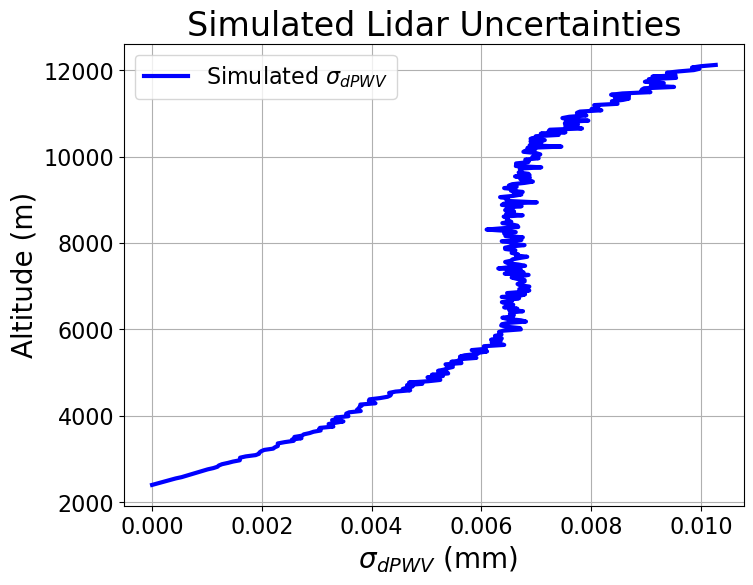

In [4]:
print(sigma_pwv)

plt.figure(figsize=(8, 6))
plt.plot(sigma_pwv, zbin + z_km[0]*1000, label="Simulated $\sigma_{dPWV}$", color="blue")
plt.ylabel("Altitude (m)")
plt.xlabel(r" $\sigma_{dPWV}$ (mm)")
plt.title("Simulated Lidar Uncertainties")
plt.legend()
plt.grid()  

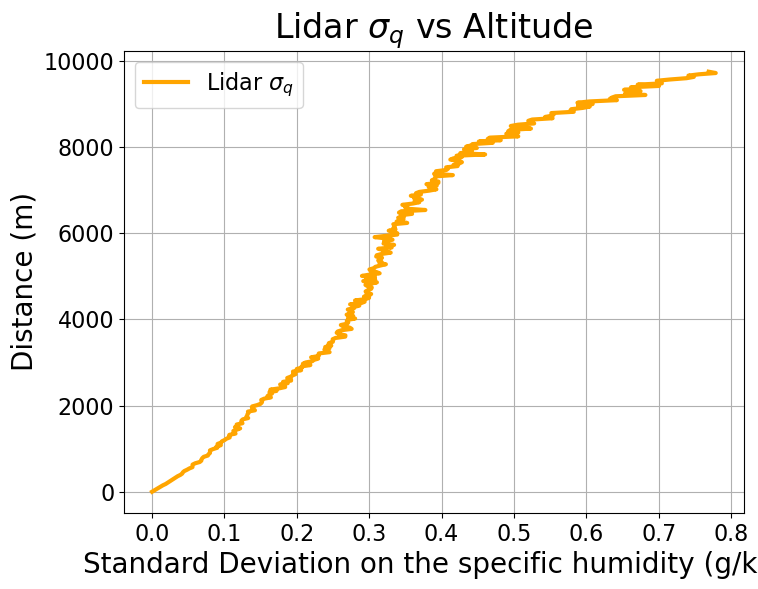

In [5]:
#Let's plot sigma_q vs altitude to see how it looks like
plt.figure(figsize=(8, 6))
plt.plot(sigma_wvmr_g_per_kg, s_km*1000, label=r"Lidar $\sigma_{q}$", color="orange")
plt.ylabel("Distance (m)")
plt.xlabel("Standard Deviation on the specific humidity (g/kg)")
plt.title(r"Lidar $\sigma_{q}$ vs Altitude")
plt.legend()
plt.grid()
plt.show()

In [6]:
kx_max = (grid_wsp.N[0] / 2.0) * grid_wsp.dk[0]
ky_max = (grid_wsp.N[1] / 2.0) * grid_wsp.dk[1]
kz_max = (grid_wsp.N[2] / 2.0) * grid_wsp.dk[2]

# 2. Calculate the extreme corner of the 3D Fourier volume
k_max_3d = np.sqrt(kx_max**2 + ky_max**2 + kz_max**2)

# 3. Create a high-resolution k_array using the smallest dk step
dk_min = np.min(grid_wsp.dk)
n_points = int(k_max_3d / dk_min) + 10  # +10 acts as a safety buffer

k_array = np.arange(n_points) * dk_min

k0_q  = 2*np.pi / L_0_q   # Water-vapour injection wavenumber (rad/m)

pofk_q  = ( k0_q**2.  + k_array**2 )**-(11/6)

# Normalise to peak = 1; absolute RMS amplitudes come from calibration.
pofk_q  /= np.max(pofk_q)

# Pack into dictionaries expected
pspec_q  = {'k': k_array, 'pofk': pofk_q}

# Next, define the fluctuation scaling profile. 
# In atmo3's calibrator, WV standard deviation is traditionally set to 1% (1e-2) of the mean:
q_std_atmosphere = q

wv_box = box.Box(
    grid_wsp=grid_wsp,
    field_name='water vapor',
    field_unit='kg / kg',
    spectrum=pspec_q, # Assuming you have your power spectrum dict ready
    zscaling={'h': z_km * 1000, 'f': q_std_atmosphere}, # Injecting your custom scaling here!
    seed=424242
)


# ==============================================================================
# 4. Generate the Field and Add the Mean
# ==============================================================================
# 1. Generate the normalized fluctuations scaled by your custom q_std_atmosphere
wv_box.generate_field_fluctuations(time_step=0)

# --- NEW PWV RECALIBRATION BLOCK ---

# A. Calculate the true Mean PWV from your 1D profiles
# (Convert specific humidity q to water vapor density rho_wv)
T_v = au.virtual_temperature(temperature_k, q) # Assuming you have 1D arrays T and q
q2rho_h2o = pressure_hpa*100 / (const.R_dry_air * T_v) # Conversion factor profile
rho_wv_mean_1d = q * q2rho_h2o

# Integrate density over altitude to get total Mean PWV
mean_pwv = jnp.trapezoid(rho_wv_mean_1d, x=z_km * 1000)

# Define your target standard deviation (1% of the mean)
target_sigma_pwv = 0.05 * mean_pwv

# B. Calculate the current PWV standard deviation of the generated fluctuations
# First, interpolate the conversion factor onto the grid's Z-axis
q2rho_interp_1d = jnp.interp(z_axis_grid, z_km * 1000, q2rho_h2o, left='extrapolate', right='extrapolate')

# Integrate the 3D specific humidity fluctuations (converted to density) along the Z-axis (axis=2)
pwv_fluctuation_plane = jnp.trapezoid(wv_box.field * q2rho_interp_1d.reshape(1, 1, -1), x=z_axis_grid, axis=2)

# Find the standard deviation of this 2D sky-plane map
current_sigma_pwv = jnp.std(pwv_fluctuation_plane)

# C. Recalibrate! (This is the exact math from atm_calibrator.calibrate_pwv)
pwv_norm = target_sigma_pwv / current_sigma_pwv
wv_box.field = wv_box.field * pwv_norm

# -----------------------------------

# The generated field is purely fluctuations (mean = 0), now perfectly calibrated to PWV!
fluctuations_3d = wv_box.field

# 2. Interpolate your custom 1D mean profile onto the exact internal z-grid
mean_interp_1d = jnp.interp(z_axis_grid, z_km * 1000, q, left='extrapolate', right='extrapolate')

# 3. Construct the total 3D field by broadcasting the 1D mean across the X and Y axes
total_wv_3d = fluctuations_3d + mean_interp_1d.reshape(1, 1, -1)

Random field : 16.119043 s
Apply P(k) : 12.544840 s
IRFFT : 0.023142 s
Rescaled field : 3.614360 s


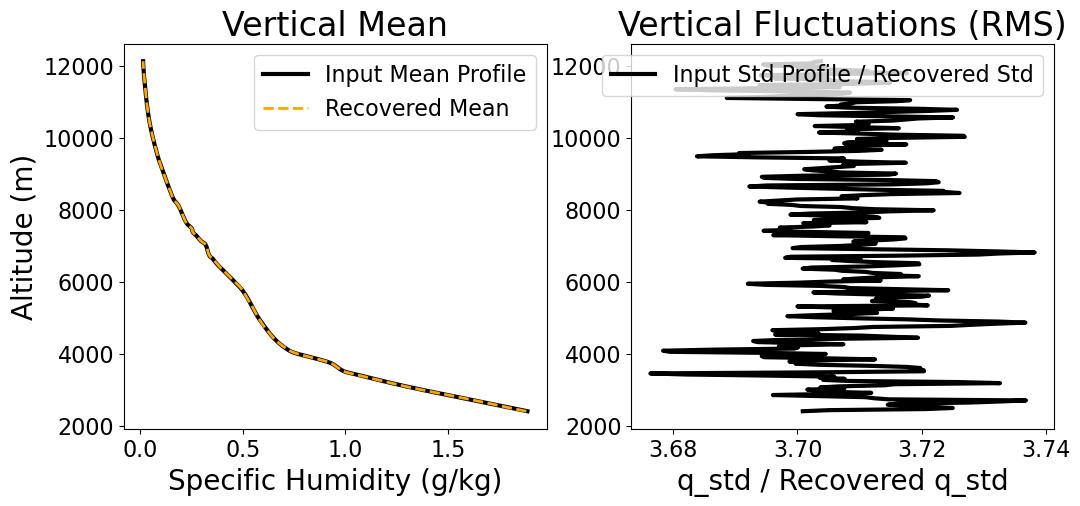

In [7]:
import matplotlib.pyplot as plt

# 1. Calculate horizontal statistics at each z-level
# axes (0, 1) represent the X and Y spatial dimensions
recovered_mean_1d = jnp.mean(total_wv_3d, axis=(0, 1))
recovered_std_1d = jnp.std(total_wv_3d, axis=(0, 1))

# 2. Plot vs your inputs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Mean Plot
ax1.plot(mean_interp_1d*1000, z_axis_grid, label='Input Mean Profile', lw=3, color='black')
ax1.plot(recovered_mean_1d*1000, z_axis_grid, '--', label='Recovered Mean', lw=2, color='orange')
ax1.set_title('Vertical Mean')
ax1.set_ylabel('Altitude (m)')
ax1.set_xlabel('Specific Humidity (g/kg)')
ax1.legend()

# Std Dev Plot
q_std_interp = jnp.interp(z_axis_grid, z_km * 1000, q_std_atmosphere)
ax2.plot(q_std_interp / recovered_std_1d, z_axis_grid, label='Input Std Profile / Recovered Std', lw=3, color='black')
ax2.set_title('Vertical Fluctuations (RMS)')
ax2.set_xlabel('q_std / Recovered q_std')
ax2.legend()

plt.show()

Target Mean PWV: 3.1642 kg/m^2
Target PWV Std (1%): 0.1582 kg/m^2
Recovered Mean PWV: 3.1632 kg/m^2
Recovered PWV Std:  0.1582 kg/m^2


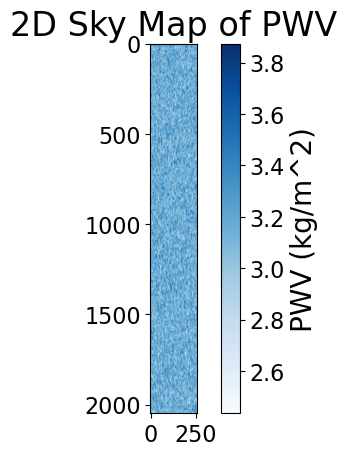

In [8]:
# Print the exact numerical targets vs reality
print(f"Target Mean PWV: {mean_pwv:.4f} kg/m^2")
print(f"Target PWV Std (1%): {target_sigma_pwv:.4f} kg/m^2")

# Recalculate the 2D plane from your FINAL total_wv_3d field
final_pwv_plane = jnp.trapezoid(total_wv_3d * q2rho_interp_1d.reshape(1, 1, -1), x=z_axis_grid, axis=2)

print(f"Recovered Mean PWV: {jnp.mean(final_pwv_plane):.4f} kg/m^2")
print(f"Recovered PWV Std:  {jnp.std(final_pwv_plane):.4f} kg/m^2")

# Plot the 2D map to visually check for artifacts
plt.imshow(final_pwv_plane, cmap='Blues')
plt.colorbar(label='PWV (kg/m^2)')
plt.title('2D Sky Map of PWV')
plt.show()

In [9]:
from atmo3.observation import Observer
import datetime

# ==============================================================================
# 5. Initialize the Observer for Wind Advection (Taylor's Hypothesis)
# ==============================================================================

# 1. Define the telescope placement
# The Observer class enforces that the boresight sits near the center of the grid's X-Y plane
boresight = jnp.array([grid_wsp.Lbox[0] / 2.0, grid_wsp.Lbox[1] / 2.0, grid_wsp.site_altitude])

# 2. Provide dummy values for passband and fwhm to satisfy the __init__ signature
dummy_passband = {'freq_GHz': jnp.array([150.0]), 'g_nu': jnp.array([1.0])}
fwhm_arcmin = 1.0

# 3. Instantiate the Observer
obs = Observer(
    grid_wsp=grid_wsp,
    boresight=boresight,
    passband=dummy_passband,
    fwhm_arcmin=fwhm_arcmin
)

# 4. Inject the constant theoretical wind (Overriding the ERA5 defaults)
obs.east_wind = vx   # 10.0 m/s along the X-axis
obs.north_wind = 0.0 # No wind along the Y-axis

# ==============================================================================
# 6. Generate the Observation Timeline and Extract the 2D Slice
# ==============================================================================

# 1. Create a 1-hour timeline of datetime objects (required by compute_los_for_scan)
total_duration = 3600 # 1 hour in seconds
n_steps = int(total_duration / dt_simulation)

start_time = np.datetime64('2026-01-01T00:00:00')
timelist = [start_time + np.timedelta64(int(i * dt_simulation), 's') for i in range(n_steps)]

# 2. Define the pointing (Staring straight up at Zenith)
azimuth_deg = [0.0] * n_steps
elevation_deg = [90.0] * n_steps

print("Computing line-of-sight coordinates through the wind...")
# This calculates the exact [x, y, z] path through the grid for every second of the 1 hour observation
obs.compute_los_for_scan(timelist, azimuth_deg, elevation_deg)

print("Extracting the 2D specific humidity slice...")
# This runs the JAX-native RegularGridInterpolator to map the coordinates to the 3D field
pristine_q_tod = obs.scan_component(total_wv_3d)

print("Extraction complete. TOD shape:", pristine_q_tod.shape) 
# Expected shape: (3600, 325) -> (Time, Altitude)

Computing line-of-sight coordinates through the wind...
Extracting the 2D specific humidity slice...
Extraction complete. TOD shape: (1800, 325)


In [10]:
# 1. Convert the loaded 1D profiles to standard SI units
P_pa_1d = pressure_hpa * 100.0  # Convert hPa to Pa

# 2. Calculate the 1D Virtual Temperature and the Conversion Factor
# Using the tools already available in atmo3.atm_utils
T_v_1d = au.virtual_temperature(temperature_k, q)
q2rho_1d = P_pa_1d / (const.R_dry_air * T_v_1d)

# 3. Interpolate the 1D conversion factor onto your exact z-grid midpoints
# (Required since z_km might not perfectly align with z_axis_grid)
q2rho_grid = jnp.interp(z_axis_grid, z_km * 1000, q2rho_1d)

# 4. Convert the entire 2D Time-Ordered Data slice from q to rho_w
# JAX automatically broadcasts the (Nz,) array across the (3600, Nz) TOD array
pristine_rhow_tod = pristine_q_tod * q2rho_grid

# 5. Perform the Bolometer Integration
# Critically, evaluate this using the midpoints of the atmospheric slabs 
# to maintain numerical accuracy across the column.
S_integrated_tod = jnp.sum(pristine_rhow_tod * dz, axis=1) # Shape: (3600,)

# ==============================================================================
# 7. Baseline Subtraction (Extracting the Perturbations)
# ==============================================================================

# 1. Bolometer: Subtract the temporal mean from the 1D integrated stream
# This mimics the removal of the static atmospheric baseline, leaving only the AC turbulence
S_mean = jnp.mean(S_integrated_tod)
S_fluct_tod = S_integrated_tod - S_mean
S_fluct_std = jnp.std(S_fluct_tod)

# 2. Lidar: Subtract the temporal mean from EACH altitude slice independently
# We take the mean along the time axis (axis 0), keeping the altitude axis (axis 1) intact
pristine_rhow_mean = jnp.mean(pristine_rhow_tod, axis=0)
pristine_rhow_fluct_tod = pristine_rhow_tod - pristine_rhow_mean

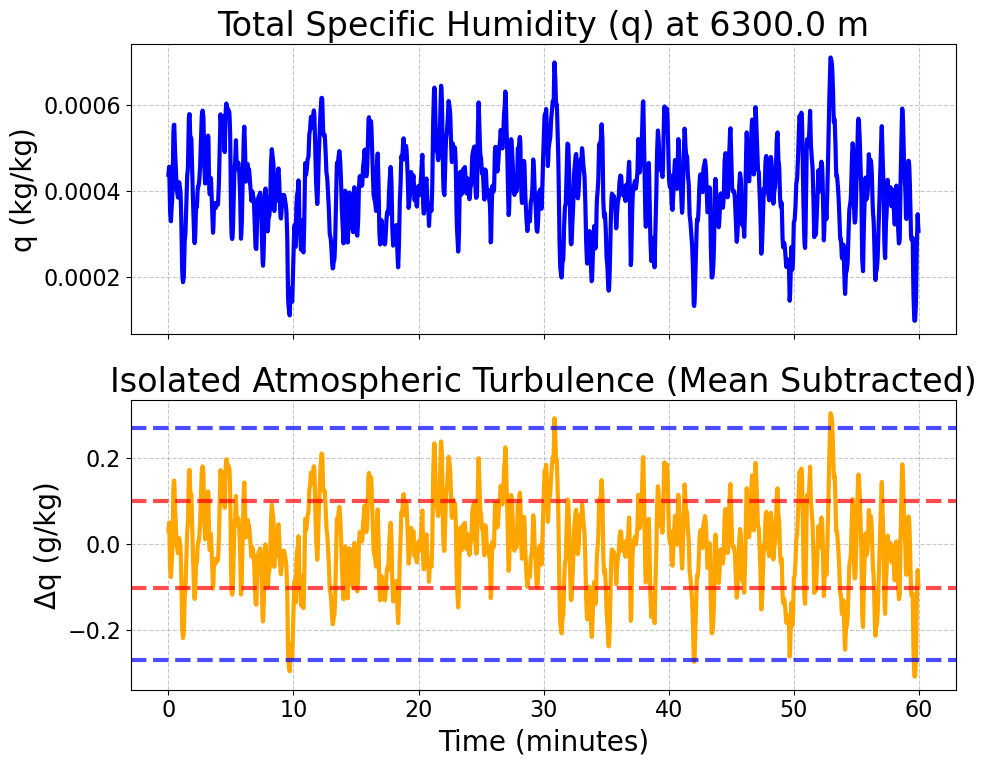

In [20]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

# Choose an altitude layer to inspect (e.g., index 50)
layer_idx = 130
altitude_m = z_axis_grid[layer_idx]


# Extract the 1D time series for this layer
q_total_1d = pristine_q_tod[:, layer_idx]

# Calculate the pure fluctuations by subtracting the time-average
q_mean = jnp.mean(q_total_1d)
q_fluct_1d = q_total_1d - q_mean

q_std_simulated = jnp.std(q_fluct_1d)
# Create a time axis for the X-axis (in minutes for easier reading)
time_minutes = np.arange(len(q_total_1d)) * dt_simulation / 60.0

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top Plot: Total Specific Humidity
ax1.plot(time_minutes, q_total_1d, color='blue')
ax1.set_title(f'Total Specific Humidity (q) at {altitude_m:.1f} m')
ax1.set_ylabel('q (kg/kg)')
ax1.grid(True, linestyle='--', alpha=0.7)
# Note: The y-axis limits here will be large, making the line look mostly flat.

#We also add +q_std_simulated to the plot for reference  and -q_std_simulated for the lower bound for the fluctuations
# Bottom Plot: Pure Fluctuations
ax2.plot(time_minutes, q_fluct_1d*1e3, color='orange')
ax2.axhline(q_std_simulated*1e3, color='red', linestyle='--', alpha=0.7)
ax2.axhline(-q_std_simulated*1e3, color='red', linestyle='--', alpha=0.7)
ax2.axhline(sigma_wvmr_g_per_kg[layer_idx], color='blue', linestyle='--', alpha=0.7)
ax2.axhline(-sigma_wvmr_g_per_kg[layer_idx], color='blue', linestyle='--', alpha=0.7)

ax2.set_title('Isolated Atmospheric Turbulence (Mean Subtracted)')
ax2.set_xlabel('Time (minutes)')
ax2.set_ylabel('Δq (g/kg)')
ax2.grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1082545/1049367383.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.axhline(q_std_simulated * 1e3, color='red', linestyle='--', alpha=0.7, label= 'Atmospheric $\sigma_{q}$')
/tmp/ipykernel_1082545/1049367383.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.axhline(sigma_wvmr_g_per_kg[layer_idx], color='blue', linestyle='--', alpha=0.7, label='Lidar $\sigma_{q}$')


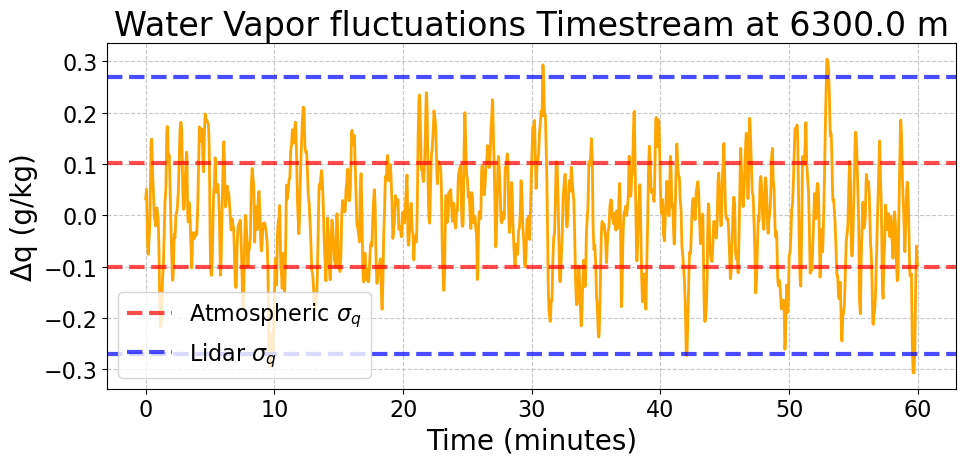

In [21]:
import matplotlib.pyplot as plt

# Water vapor fluctuations timestream only
plt.figure(figsize=(10, 5))
plt.plot(time_minutes, q_fluct_1d * 1e3, color='orange', linewidth=2)
plt.axhline(q_std_simulated * 1e3, color='red', linestyle='--', alpha=0.7, label= 'Atmospheric $\sigma_{q}$')
plt.axhline(-q_std_simulated * 1e3, color='red', linestyle='--', alpha=0.7)
plt.axhline(sigma_wvmr_g_per_kg[layer_idx], color='blue', linestyle='--', alpha=0.7, label='Lidar $\sigma_{q}$')
plt.axhline(-sigma_wvmr_g_per_kg[layer_idx], color='blue', linestyle='--', alpha=0.7)

plt.title(f'Water Vapor fluctuations Timestream at {altitude_m:.1f} m')
plt.xlabel('Time (minutes)')
plt.ylabel('Δq (g/kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

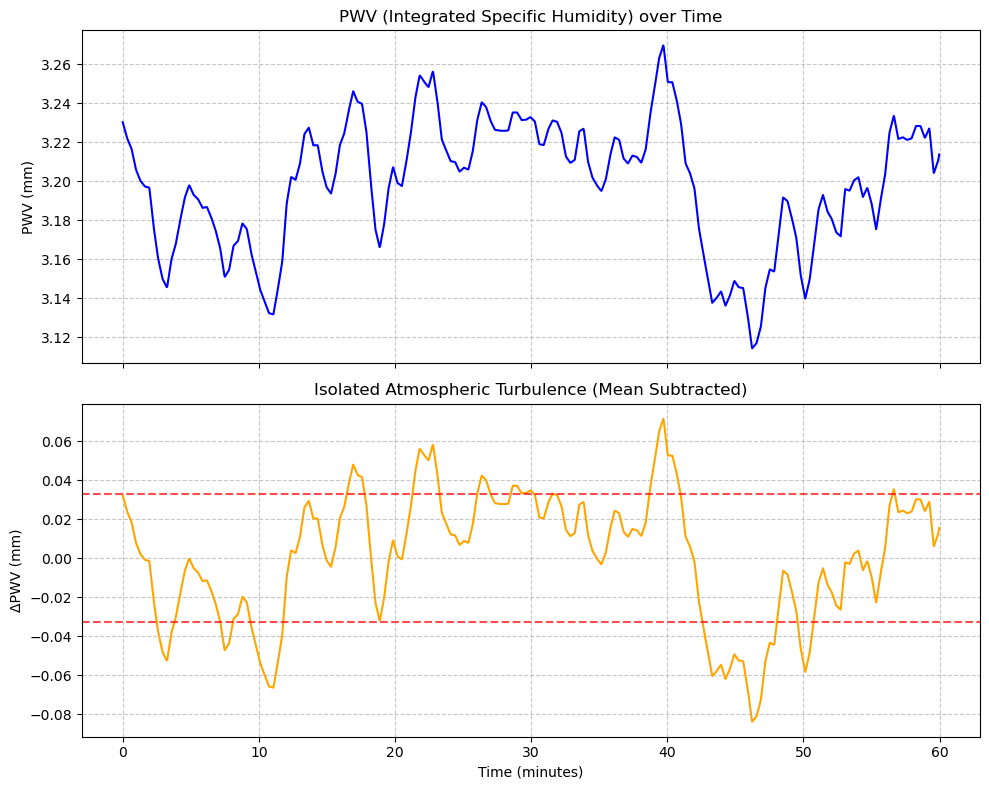

In [66]:
#Let's plot PWV as a function of time, to see the fluctuations in the integrated column during the scan

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top Plot: Total Specific Humidity
ax1.plot(time_minutes, S_integrated_tod, color='blue')
ax1.set_title(f'PWV (Integrated Specific Humidity) over Time')
ax1.set_ylabel('PWV (mm)')
ax1.grid(True, linestyle='--', alpha=0.7)
# Note: The y-axis limits here will be large, making the line look mostly flat.

#We also add +S_fluct_std to the plot for reference  and -S_fluct_std for the lower bound for the fluctuations
# Bottom Plot: Pure Fluctuations
ax2.plot(time_minutes, S_fluct_tod, color='orange')
ax2.axhline(S_fluct_std, color='red', linestyle='--', alpha=0.7)
ax2.axhline(-S_fluct_std, color='red', linestyle='--', alpha=0.7)


ax2.set_title('Isolated Atmospheric Turbulence (Mean Subtracted)')
ax2.set_xlabel('Time (minutes)')
ax2.set_ylabel('ΔPWV (mm)')
ax2.grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

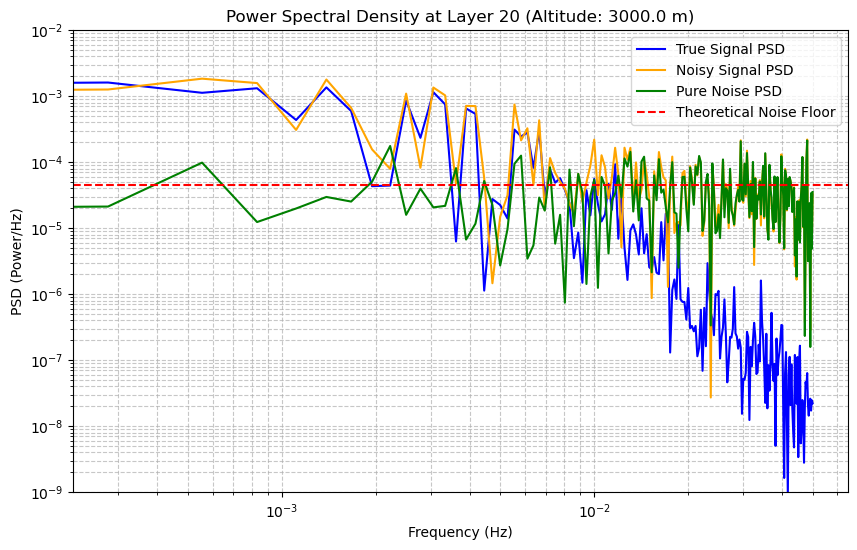

In [67]:
import jax.numpy as jnp
import jax.random as random

# ==============================================================================
# 1. Forward Model the Lidar Observations (Parameter-Proof)
# ==============================================================================

dt_lidar = 10.0 # Fixed by the calibration in your Tenerife .txt file

# 1. Dynamically calculate how many simulation frames make up one 10-second Lidar shot
# Note: Ensure your dt_simulation divides 10.0 cleanly (e.g., 1.0, 2.0, 2.5, 5.0)
frames_per_lidar = int(dt_lidar / dt_simulation)

# 2. Determine the maximum number of full Lidar samples we can extract
total_simulation_frames = pristine_rhow_fluct_tod.shape[0]
n_lidar_samples = total_simulation_frames // frames_per_lidar

# 3. Truncate any leftover frames at the tail end to guarantee a perfect reshape
valid_frames_count = n_lidar_samples * frames_per_lidar
pristine_truncated = pristine_rhow_fluct_tod[:valid_frames_count, :]

# 4. Reshape and average using JAX vectorization
pristine_10s_blocks = pristine_truncated.reshape(n_lidar_samples, frames_per_lidar, Nz)
pristine_rhow_10s = jnp.mean(pristine_10s_blocks, axis=1) # Shape: (n_lidar_samples, Nz)

# 5. Convert volumetric density (kg/m^3) to Layer PWV (kg/m^2)
pristine_layer_pwv_10s = pristine_rhow_10s * dz 

# 6. Generate and Add the Lidar Noise
key = random.PRNGKey(42)

# sigma_pwv broadcasts natively across the (n_lidar_samples, Nz) array
lidar_noise_2d = random.normal(key, shape=(n_lidar_samples, Nz)) * sigma_pwv
noisy_lidar_pwv_10s = pristine_layer_pwv_10s + lidar_noise_2d

# ==============================================================================
# 2. Calculate the Power Spectral Densities (PSD) for a specific layer
# ==============================================================================

# Pick a layer in the lower atmosphere, e.g., index 50 (1500m above site)
layer_idx = 20

# Extract the 1D time series for this specific layer
true_signal_1d = pristine_layer_pwv_10s[:, layer_idx]
noisy_signal_1d = noisy_lidar_pwv_10s[:, layer_idx]
pure_noise_1d = lidar_noise_2d[:, layer_idx]

true_signal_1d = true_signal_1d - jnp.mean(true_signal_1d)  # Remove any DC offset for the true signal
noisy_signal_1d = noisy_signal_1d - jnp.mean(noisy_signal_1d)  # Remove any DC offset for the noisy signal
pure_noise_1d = pure_noise_1d - jnp.mean(pure_noise_1d)  # Remove any DC offset for the noise

# Time parameters for the FFT
dt_lidar = 10.0 # seconds
fs_lidar = 1.0 / dt_lidar

# 1. Compute the FFT (Real-to-Complex)
fft_true = jnp.fft.rfft(true_signal_1d)
fft_noisy = jnp.fft.rfft(noisy_signal_1d)
fft_noise = jnp.fft.rfft(pure_noise_1d)

# 2. Calculate the PSD (Power / Hz)
# Multiplying by 2.0 accounts for the power folded over from negative frequencies
psd_true = (2.0 / (fs_lidar * n_lidar_samples)) * jnp.abs(fft_true)**2
psd_noisy = (2.0 / (fs_lidar * n_lidar_samples)) * jnp.abs(fft_noisy)**2
psd_noise = (2.0 / (fs_lidar * n_lidar_samples)) * jnp.abs(fft_noise)**2

# 3. Get the corresponding frequency bins for the X-axis
freqs = jnp.fft.rfftfreq(n_lidar_samples, d=dt_lidar)

# Calculate the theoretical flat noise floor for this specific Lidar layer
theoretical_noise_level = 2.0 * (sigma_pwv[layer_idx]**2) / fs_lidar

# Plot the PSDs
plt.figure(figsize=(10, 6))
plt.loglog(freqs, psd_true, label='True Signal PSD', color='blue')
plt.loglog(freqs, psd_noisy, label='Noisy Signal PSD', color='orange')
plt.loglog(freqs, psd_noise, label='Pure Noise PSD', color='green')
plt.axhline(theoretical_noise_level, color='red', linestyle='--', label='Theoretical Noise Floor')
plt.title(f'Power Spectral Density at Layer {layer_idx} (Altitude: {z_axis_grid[layer_idx]:.1f} m)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (Power/Hz)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.ylim(1e-9, 1e-2)
plt.show()


In [68]:
print(true_signal_1d.shape, noisy_signal_1d.shape, pure_noise_1d.shape)

(360,) (360,) (360,)


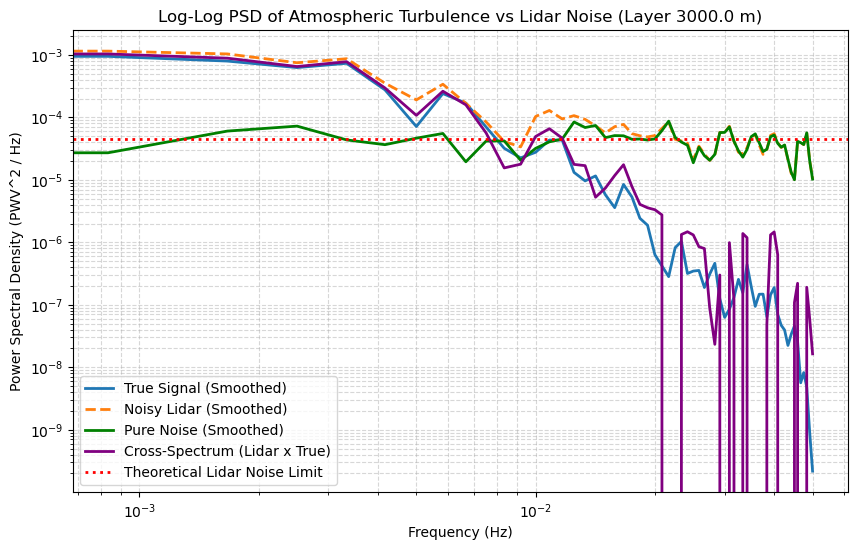

In [93]:
import matplotlib.pyplot as plt
from scipy.signal import welch, csd
import jax.numpy as jnp

layer_idx = 20

n_window = 120  # Number of samples per segment for Welch's method

# 1. Isolate the 1D arrays and strictly remove the local residual mean
true_signal_1d = pristine_layer_pwv_10s[:, layer_idx]
noisy_signal_1d = noisy_lidar_pwv_10s[:, layer_idx]
pure_noise_1d = lidar_noise_2d[:, layer_idx]

true_signal_1d -= jnp.mean(true_signal_1d)
noisy_signal_1d -= jnp.mean(noisy_signal_1d)
pure_noise_1d -= jnp.mean(pure_noise_1d)

# 2. Use Welch's Method to calculate a smoothed PSD
# nperseg controls the smoothing. A window of ~120 gives 3 averaged blocks for your 360-element array.
freqs_true, psd_true_smooth = welch(true_signal_1d, fs=fs_lidar, nperseg=n_window)
freqs_noisy, psd_noisy_smooth = welch(noisy_signal_1d, fs=fs_lidar, nperseg=n_window)
freqs_noise, psd_noise_smooth = welch(pure_noise_1d, fs=fs_lidar, nperseg=n_window)


# Cross-Spectrum (CPSD)
# Note: CPSD can be complex, but for highly correlated physical signals, 
# the magnitude (abs) contains the shared power.
freqs_cross, cpsd_complex = csd(noisy_signal_1d, true_signal_1d, fs=fs_lidar, nperseg=n_window)
#cpsd_mag = jnp.abs(cpsd_complex)
cpsd_mag = jnp.real(cpsd_complex)

# Calculate S* X
_, csd_sx = csd(true_signal_1d, noisy_signal_1d, fs=fs_lidar, nperseg=n_window)

# Calculate X* S
_, csd_xs = csd(noisy_signal_1d, true_signal_1d, fs=fs_lidar, nperseg=n_window)

# Apply the formula: 1/2 * (S* X + X* S)
cpsd_test = 0.5 * (csd_sx + csd_xs)
cpds_test = jnp.real(cpsd_test)

theoretical_noise_level = 2.0 * (sigma_pwv[layer_idx]**2) / fs_lidar
# 3. Plotting on a Log-Log Scale
plt.figure(figsize=(10, 6))

# Plot the smoothed Welch periodograms
plt.loglog(freqs_true, psd_true_smooth, label='True Signal (Smoothed)', linewidth=2)
plt.loglog(freqs_noisy, psd_noisy_smooth, label='Noisy Lidar (Smoothed)', linestyle='--', linewidth=2)
plt.loglog(freqs_noise, psd_noise_smooth, label='Pure Noise (Smoothed)', color = 'green', linewidth=2)
plt.loglog(freqs_cross, cpsd_mag, label='Cross-Spectrum (Lidar x True)', color='purple', linewidth=2)
#plt.loglog(freqs_cross, cpsd_test, label='Test Cross-Spectrum', color='orange', linewidth=2)
# Plot it as a straight red dotted line
plt.axhline(theoretical_noise_level, color='red', linestyle=':', linewidth=2, label='Theoretical Lidar Noise Limit')

# Optional: You can still plot the raw FFT underneath with high transparency (alpha=0.2) 
# if you want to see the jagged comb hiding behind the smooth line.

plt.title(f'Log-Log PSD of Atmospheric Turbulence vs Lidar Noise (Layer {z_axis_grid[layer_idx]:.1f} m)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (PWV^2 / Hz)')
plt.grid(True, which="both", ls="--", alpha=0.5) # Turn on minor grid lines for log scales
#plt.ylim(1e-5, 1e-3)
plt.legend()
plt.show()

In [84]:
print(cpsd_complex)

[ 1.09673430e-05+0.00000000e+00j  4.74105462e-05-7.17810118e-06j
  1.21928047e-04-1.53426105e-05j  1.35989909e-04-5.11045984e-05j
  1.07936508e-04-2.65620308e-05j  7.25946581e-05+1.08451173e-06j
  2.62227193e-05-2.76954614e-06j -1.94373601e-05-5.93250783e-06j
 -2.46672341e-05-1.88352318e-05j  2.56043901e-06-1.21032496e-05j
 -1.00889520e-05-1.41058203e-05j -1.18776843e-05-1.03581390e-05j
  8.01766327e-06+7.13555107e-06j  3.30280443e-06+6.75880723e-06j
  4.35849376e-06+1.43478893e-05j  1.35190494e-05+1.66475369e-05j
  3.39898520e-06+1.36366633e-06j  8.37455932e-06+2.56034022e-06j
  4.71393925e-06+8.94460542e-06j  2.68222915e-06-5.44164391e-06j
 -7.55109547e-06-1.00780242e-05j  7.96510344e-07+1.89797022e-06j
  1.96033020e-06+4.04427732e-06j  2.83722385e-06+1.29499087e-06j
  6.49580272e-06-1.93715833e-06j  2.29700303e-06-3.35289532e-06j
  8.67676928e-07-1.16008649e-06j  1.14258348e-06-6.42511023e-07j
  6.39228731e-07-1.48465594e-06j -1.84363868e-07+2.83463557e-07j
 -2.01864445e-06+4.763171

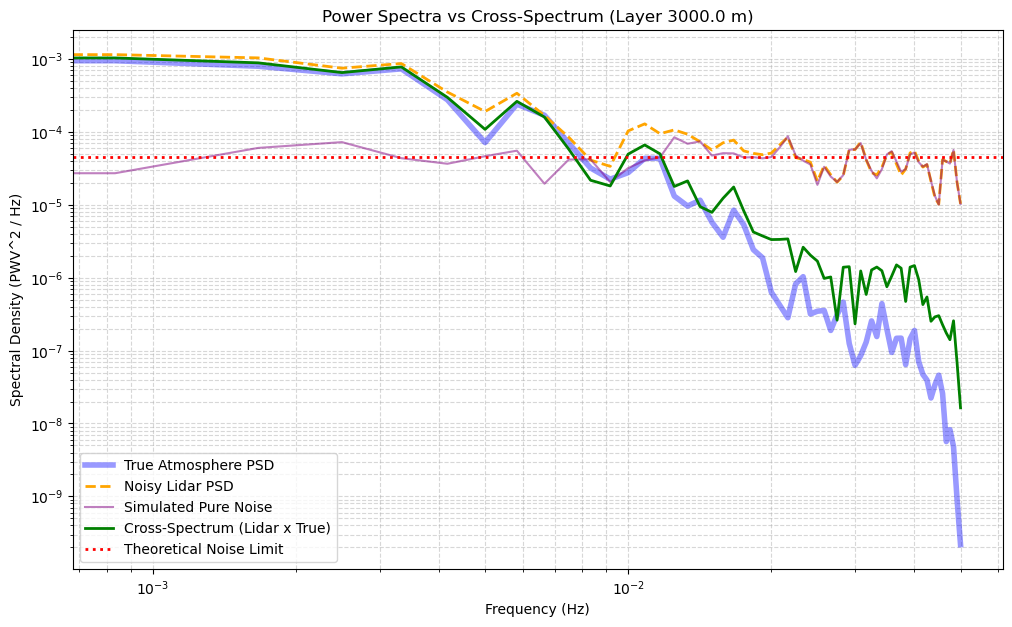

In [73]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from scipy.signal import welch, csd

layer_idx = 20

# ==============================================================================
# 1. Isolate the 1D arrays and strictly remove the local residual mean
# ==============================================================================
true_signal_1d = pristine_layer_pwv_10s[:, layer_idx]
noisy_signal_1d = noisy_lidar_pwv_10s[:, layer_idx]
pure_noise_1d = lidar_noise_2d[:, layer_idx]

true_signal_1d -= jnp.mean(true_signal_1d)
noisy_signal_1d -= jnp.mean(noisy_signal_1d)
pure_noise_1d -= jnp.mean(pure_noise_1d)

# ==============================================================================
# 2. Use Welch's Method to calculate smoothed PSDs and CPSD
# ==============================================================================
# nperseg controls the smoothing. A window of 120 gives 3 averaged blocks for your 360-element array.
n_window = 120

# Auto-Spectra (PSD)
freqs_true, psd_true_smooth = welch(true_signal_1d, fs=fs_lidar, nperseg=n_window)
freqs_noisy, psd_noisy_smooth = welch(noisy_signal_1d, fs=fs_lidar, nperseg=n_window)
freqs_noise, psd_noise_smooth = welch(pure_noise_1d, fs=fs_lidar, nperseg=n_window)

# Cross-Spectrum (CPSD)
# Note: CPSD can be complex, but for highly correlated physical signals, 
# the magnitude (abs) contains the shared power.
freqs_cross, cpsd_complex = csd(noisy_signal_1d, true_signal_1d, fs=fs_lidar, nperseg=n_window)
cpsd_mag = jnp.abs(cpsd_complex)

# ==============================================================================
# 3. Calculate Theoretical Limits and Plot
# ==============================================================================
# The theoretical limit: 2 * variance / sampling_rate
theoretical_noise_level = 2.0 * (sigma_pwv[layer_idx]**2) / fs_lidar

plt.figure(figsize=(12, 7))

# Plot the PSDs
plt.loglog(freqs_true, psd_true_smooth, label='True Atmosphere PSD', color='blue', linewidth=4, alpha=0.4)
plt.loglog(freqs_noisy, psd_noisy_smooth, label='Noisy Lidar PSD', color='orange', linestyle='--', linewidth=2)
plt.loglog(freqs_noise, psd_noise_smooth, label='Simulated Pure Noise', color='purple', alpha=0.5)

# Plot the Cross-Spectrum
plt.loglog(freqs_cross, cpsd_mag, label='Cross-Spectrum (Lidar x True)', color='green', linewidth=2)

# Plot the Theoretical Limit
plt.axhline(theoretical_noise_level, color='red', linestyle=':', linewidth=2, label='Theoretical Noise Limit')

plt.title(f'Power Spectra vs Cross-Spectrum (Layer {z_axis_grid[layer_idx]:.1f} m)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Spectral Density (PWV^2 / Hz)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

Let's try to not downsample but to upsample

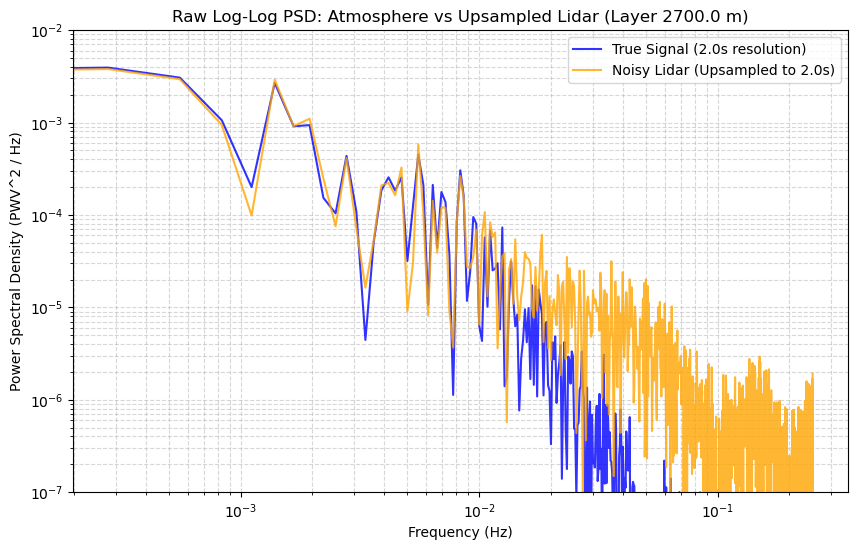

In [72]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Choose the layer to analyze (e.g., index 1)
layer_idx = 10
altitude_m = z_axis_grid[layer_idx]

# ==============================================================================
# 1. Align the Time Domains
# ==============================================================================
dt_lidar = 10.0 # Fixed by the calibration in your Tenerife .txt file

# 1. Dynamically calculate how many simulation frames make up one 10-second Lidar shot
# Note: Ensure your dt_simulation divides 10.0 cleanly (e.g., 1.0, 2.0, 2.5, 5.0)
frames_per_lidar = int(dt_lidar / dt_simulation)

fs_sim = 1.0 / dt_simulation #in Hz

# Extract the True Signal at the native 2.0s resolution
# Note: pristine_rhow_fluct_tod represents density. Multiply by dz to get PWV (kg/m^2)
true_signal_2s = pristine_rhow_fluct_tod[:, layer_idx] * dz 

# Ensure lengths match perfectly by truncating any fractional tail
valid_sim_frames = len(noisy_lidar_pwv_10s) * frames_per_lidar
true_signal_2s = true_signal_2s[:valid_sim_frames]

# Extract the 10s Noisy Lidar signal and UPSAMPLE it to 2.0s using Zero-Order Hold
noisy_lidar_10s = noisy_lidar_pwv_10s[:, layer_idx]
noisy_lidar_2s = jnp.repeat(noisy_lidar_10s, frames_per_lidar)

# Strictly remove the mean to prevent DC leakage in the FFT
true_signal_2s -= jnp.mean(true_signal_2s)
noisy_lidar_2s -= jnp.mean(noisy_lidar_2s)

# ==============================================================================
# 2. Raw FFT and PSD Calculation
# ==============================================================================
N_samples = len(true_signal_2s)

# 1. Compute the Raw FFTs
fft_true = jnp.fft.rfft(true_signal_2s)
fft_lidar = jnp.fft.rfft(noisy_lidar_2s)

# 2. Convert to Power Spectral Density (Power / Hz)
# The factor of 2.0 accounts for the symmetric negative frequencies folded over by rfft
psd_true = (2.0 / (fs_sim * N_samples)) * jnp.abs(fft_true)**2
psd_lidar = (2.0 / (fs_sim * N_samples)) * jnp.abs(fft_lidar)**2

# 3. Generate the shared frequency axis (up to 0.25 Hz)
freqs = jnp.fft.rfftfreq(N_samples, d=dt_simulation)

# ==============================================================================
# 3. Plotting the Aligned Spectra
# ==============================================================================
plt.figure(figsize=(10, 6))

# Plotting the raw, un-smoothed periodograms
plt.loglog(freqs, psd_true, label='True Signal (2.0s resolution)', color='blue', alpha=0.8)
plt.loglog(freqs, psd_lidar, label='Noisy Lidar (Upsampled to 2.0s)', color='orange', alpha=0.8)

plt.ylim(1e-7, 1e-2)

plt.title(f'Raw Log-Log PSD: Atmosphere vs Upsampled Lidar (Layer {altitude_m:.1f} m)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (PWV^2 / Hz)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()